In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# On charge les deux tables brutes générées par data_generation/run_generation.py
clients = pd.read_parquet("../data/raw/clients.parquet")
transactions = pd.read_parquet("../data/raw/transactions.parquet")

# Premier réflexe face à un nouveau dataset : combien de lignes, quelle granularité
print("Table clients :", clients.shape)
print("Table transactions :", transactions.shape)
print()

# La granularité doit être claire avant d'aller plus loin :
# - clients : une ligne = un client
# - transactions : une ligne = un client, pour un mois donné
print("Une ligne de 'clients' = un client")
print("Une ligne de 'transactions' = un client, un mois donné")
print()

# La colonne 'mois' est un index relatif (0 à 17), pas une vraie date calendaire
print("Période couverte : mois", transactions["mois"].min(), "à", transactions["mois"].max())
print()

# Aperçu rapide de la table clients
clients.head(3)

Table clients : (2000, 5)
Table transactions : (36000, 8)

Une ligne de 'clients' = un client
Une ligne de 'transactions' = un client, un mois donné

Période couverte : mois 0 à 17



,client_id,age,statut_pro,anciennete_mois,profil_trajectoire
0,CLI_00001,67,retraite,138,degradation_progressive
1,CLI_00002,28,salarie,24,stable
2,CLI_00003,22,etudiant,77,stable


In [2]:
# On vérifie qu'il n'y a aucune valeur manquante dans les deux tables
print("Valeurs manquantes - clients :")
print(clients.isnull().sum())
print()

print("Valeurs manquantes - transactions :")
print(transactions.isnull().sum())
print()

# On vérifie qu'aucun client n'est dupliqué dans la table clients
print("Doublons de client_id :", clients["client_id"].duplicated().sum())
print()

# On vérifie qu'il n'y a pas deux lignes pour le même client au même mois
print("Doublons (client_id, mois) :", transactions.duplicated(subset=["client_id", "mois"]).sum())

Valeurs manquantes - clients :
client_id             0
age                   0
statut_pro            0
anciennete_mois       0
profil_trajectoire    0
dtype: int64

Valeurs manquantes - transactions :
client_id                0
mois                     0
revenus_entrants         0
depenses_contraintes     0
depenses_variables       0
solde_fin_mois           0
nb_incidents_paiement    0
nb_decouverts            0
dtype: int64

Doublons de client_id : 0

Doublons (client_id, mois) : 0


Répartition par statut professionnel :
statut_pro
salarie        0.547
retraite       0.152
independant    0.144
etudiant       0.104
sans_emploi    0.052
Name: proportion, dtype: float64

Âge - statistiques globales :
count    2000.0
mean       42.8
std        16.1
min        18.0
25%        31.0
50%        41.0
75%        52.0
max        85.0
Name: age, dtype: float64

Ancienneté (mois) - statistiques globales :
count    2000.0
mean      117.7
std        69.5
min         1.0
25%        59.0
50%       117.0
75%       177.0
max       240.0
Name: anciennete_mois, dtype: float64



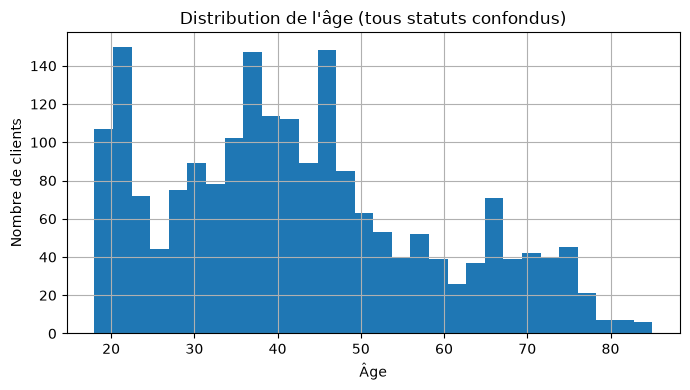

In [3]:
# Répartition par statut professionnel : combien de clients dans chaque catégorie
print("Répartition par statut professionnel :")
print(clients["statut_pro"].value_counts(normalize=True).round(3))
print()

# Âge : vue d'ensemble
print("Âge - statistiques globales :")
print(clients["age"].describe().round(1))
print()

# Ancienneté du compte : vue d'ensemble
print("Ancienneté (mois) - statistiques globales :")
print(clients["anciennete_mois"].describe().round(1))
print()

# Visualisation : distribution de l'âge, toutes populations confondues
clients["age"].hist(bins=30, figsize=(7, 4))
plt.title("Distribution de l'âge (tous statuts confondus)")
plt.xlabel("Âge")
plt.ylabel("Nombre de clients")
plt.tight_layout()
plt.show()

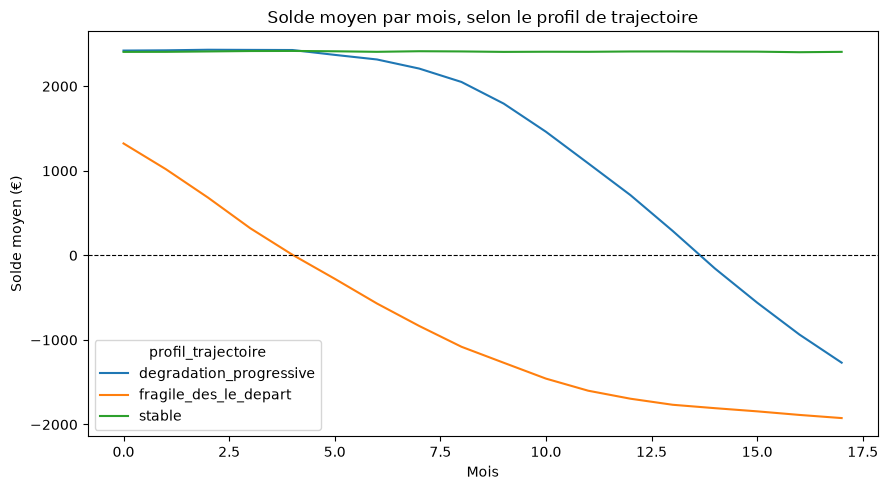

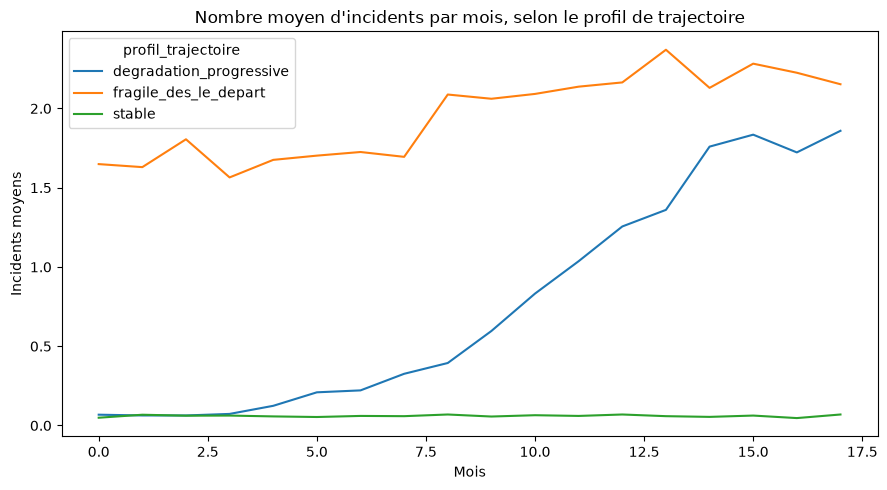

In [4]:
# On assemble les deux tables : chaque ligne de transaction avec le profil du client associé
merged = transactions.merge(clients[["client_id", "profil_trajectoire"]], on="client_id")

# Évolution moyenne du solde par mois, une courbe par profil de trajectoire
solde_moyen_par_mois = merged.groupby(["mois", "profil_trajectoire"])["solde_fin_mois"].mean().unstack()

solde_moyen_par_mois.plot(figsize=(9, 5))
plt.title("Solde moyen par mois, selon le profil de trajectoire")
plt.xlabel("Mois")
plt.ylabel("Solde moyen (€)")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

# Même logique pour les incidents de paiement
incidents_moyen_par_mois = merged.groupby(["mois", "profil_trajectoire"])["nb_incidents_paiement"].mean().unstack()

incidents_moyen_par_mois.plot(figsize=(9, 5))
plt.title("Nombre moyen d'incidents par mois, selon le profil de trajectoire")
plt.xlabel("Mois")
plt.ylabel("Incidents moyens")
plt.tight_layout()
plt.show()

In [10]:
print("Nouvelle distribution de fragile_legal :")
print(transactions["fragile_legal"].value_counts(normalize=True).round(3))
print()
print("Répartition des deux critères (avant combinaison) :")
print("Critère incidents + ressources :", transactions["critere_incidents_ressources"].mean().round(3))
print("Critère 3 mois consécutifs :", transactions["incidents_3_mois_consecutifs"].mean().round(3))

Nouvelle distribution de fragile_legal :
fragile_legal
0    0.968
1    0.032
Name: proportion, dtype: float64

Répartition des deux critères (avant combinaison) :


KeyError: 'critere_incidents_ressources'

In [5]:
# On repère, pour chaque client, le premier mois où son solde passe en négatif
# C'est un événement observable dans les données, sans utiliser le profil caché
premier_mois_negatif = (
    merged[merged["solde_fin_mois"] < 0]
    .groupby("client_id")["mois"]
    .min()
)

print(f"{len(premier_mois_negatif)} clients sur {len(clients)} passent en solde négatif au moins une fois")
print()

# On garde seulement ceux dont la bascule arrive après le mois 3
# (il faut au moins 3 mois d'historique "avant" pour pouvoir observer quelque chose)
clients_avec_bascule = premier_mois_negatif[premier_mois_negatif >= 3]

# Pour chacun de ces clients, on récupère ses valeurs 3, 2 et 1 mois avant sa bascule
rows = []
for cid, mois_bascule in clients_avec_bascule.items():
    historique = merged[merged["client_id"] == cid]
    for offset in [-3, -2, -1]:
        ligne = historique[historique["mois"] == mois_bascule + offset]
        if not ligne.empty:
            rows.append({
                "mois_relatif": offset,
                "revenus_entrants": ligne["revenus_entrants"].values[0],
                "depenses_contraintes": ligne["depenses_contraintes"].values[0],
                "nb_decouverts": ligne["nb_decouverts"].values[0],
                "nb_incidents_paiement": ligne["nb_incidents_paiement"].values[0],
            })

avant_bascule = pd.DataFrame(rows)
avant_bascule["ratio_charges_revenu"] = avant_bascule["depenses_contraintes"] / avant_bascule["revenus_entrants"]

# On regarde l'évolution moyenne de chaque indicateur, mois par mois, à l'approche de la bascule
avant_bascule.groupby("mois_relatif")[
    ["revenus_entrants", "ratio_charges_revenu", "nb_decouverts", "nb_incidents_paiement"]
].mean().round(2)

607 clients sur 2000 passent en solde négatif au moins une fois



,revenus_entrants,ratio_charges_revenu,nb_decouverts,nb_incidents_paiement
mois_relatif,,,,
-3,1435.69,0.51,2.55,1.12
-2,1422.42,0.54,2.78,1.25
-1,1337.94,0.60,2.87,1.38


## 1) Cible métier : target_fragile_j3m

On veut détecter un client qui n'est pas encore dans le seuil réglementaire,
mais qui va l'atteindre dans les 3 prochains mois.

Cette cible est exactement la bonne cible métier pour un signal d'alerte précoce.


In [6]:
# 1) Cible métier : target_fragile_j3m
# Un client est "fragile_legal" au mois M s'il a au moins 5 incidents de paiement
# ou 5 découverts dans le mois, avec un solde final négatif.
transactions = transactions.sort_values(["client_id", "mois"]).copy()
transactions["fragile_legal"] = (
    ((transactions["nb_incidents_paiement"] >= 5) & (transactions["solde_fin_mois"] <= 0))
    | ((transactions["nb_decouverts"] >= 5) & (transactions["solde_fin_mois"] <= 0))
).astype(int)

# On crée les indicateurs du futur sur 1, 2 et 3 mois
for lag in [1, 2, 3]:
    transactions[f"fragile_legal_lag{lag}"] = (
        transactions.groupby("client_id")["fragile_legal"].shift(-lag).fillna(0).astype(int)
    )

# La cible vaut 1 si le client n'est pas déjà fragile aujourd'hui,
# mais le devient dans les 3 prochains mois.
transactions["target_fragile_j3m"] = (
    (transactions["fragile_legal"] == 0)
    & (
        (transactions["fragile_legal_lag1"] == 1)
        | (transactions["fragile_legal_lag2"] == 1)
        | (transactions["fragile_legal_lag3"] == 1)
    )
).astype(int)

# On enlève les derniers mois trop proches de la fin de séquence pour éviter 
# un horizon d'observation insuffisant.
transactions = transactions[transactions["mois"] <= transactions["mois"].max() - 3].copy()

print("Distribution de target_fragile_j3m :")
print(transactions["target_fragile_j3m"].value_counts(normalize=True).round(3).to_string())
print()
print(transactions[["client_id", "mois", "fragile_legal", "target_fragile_j3m"]].head(12).to_string(index=False))


Distribution de target_fragile_j3m :
target_fragile_j3m
0    0.924
1    0.076

client_id  mois  fragile_legal  target_fragile_j3m
CLI_00001     0              0                   0
CLI_00001     1              0                   0
CLI_00001     2              0                   0
CLI_00001     3              0                   0
CLI_00001     4              0                   0
CLI_00001     5              0                   0
CLI_00001     6              0                   0
CLI_00001     7              0                   0
CLI_00001     8              0                   0
CLI_00001     9              0                   0
CLI_00001    10              0                   0
CLI_00001    11              0                   0


## 2) Features d'alerte comportementales

Pour détecter un risque avant le seuil réglementaire, les variables les plus pertinentes sont :
- évolution du solde et du ratio solde / revenu,
- baisses de revenus et hausse des dépenses contraintes,
- incidents de paiement et découverts,
- écarts par rapport aux moyennes récentes (rolling 3 et 6 mois),
- profil client de base et ancienneté.

Le but est de capturer la phase de dégradation progressive, pas l'état déjà fragile.


In [7]:
import numpy as np

# 2) Construction des features d'alerte
clients = pd.read_parquet("../data/raw/clients.parquet")
model_df = transactions.merge(
    clients[["client_id", "age", "statut_pro", "anciennete_mois"]],
    on="client_id",
    how="left",
)

for col in [
    "revenus_entrants",
    "depenses_contraintes",
    "depenses_variables",
    "solde_fin_mois",
    "nb_incidents_paiement",
    "nb_decouverts",
]:
    model_df[f"{col}_lag1"] = model_df.groupby("client_id")[col].shift(1).fillna(0)
    model_df[f"{col}_delta"] = model_df.groupby("client_id")[col].diff(1).fillna(0)
    model_df[f"{col}_roll3"] = model_df.groupby("client_id")[col].transform(
        lambda s: s.rolling(3, min_periods=1).mean().fillna(0)
    )
    model_df[f"{col}_roll6"] = model_df.groupby("client_id")[col].transform(
        lambda s: s.rolling(6, min_periods=1).mean().fillna(0)
    )

model_df["solde_to_revenu_ratio"] = (
    model_df["solde_fin_mois"] / model_df["revenus_entrants"].replace(0, np.nan)
).fillna(0)
model_df["tension_financiere"] = (
    model_df["nb_incidents_paiement"] + 1.5 * model_df["nb_decouverts"] - 0.001 * model_df["solde_fin_mois"]
)

# Encodage catégoriel des statuts professionnels.
model_df = pd.get_dummies(model_df, columns=["statut_pro"], prefix="statut", drop_first=True)

print("Aperçu des features créées :")
print(model_df[[
    "client_id", "mois", "solde_fin_mois", "solde_to_revenu_ratio",
    "nb_incidents_paiement", "nb_decouverts", "tension_financiere", "target_fragile_j3m"
]].head(10).to_string(index=False))


Aperçu des features créées :
client_id  mois  solde_fin_mois  solde_to_revenu_ratio  nb_incidents_paiement  nb_decouverts  tension_financiere  target_fragile_j3m
CLI_00001     0         2026.46               1.267520                      1              0            -1.02646                   0
CLI_00001     1         2107.87               1.406897                      0              1            -0.60787                   0
CLI_00001     2         2180.65               1.347444                      0              0            -2.18065                   0
CLI_00001     3         1903.84               1.444941                      0              1            -0.40384                   0
CLI_00001     4         2064.49               1.241358                      1              1             0.43551                   0
CLI_00001     5         1981.09               1.334202                      2              1             1.51891                   0
CLI_00001     6         2117.11         

## 3) Baseline de détection anticipée

Le but est de tester un premier modèle simple, interprétable, sur une cible de détection anticipée dans les 3 mois.

Nous utilisons une séparation temporelle strictement chronologique :
- entraînement sur les mois les plus anciens,
- test sur les mois plus récents,
- et nous évaluons par rappel / précision / AUPRC, car la cible est rare.

La logique n’est pas de prédire "déjà fragile" mais de signaler une dégradation qui va se matérialiser dans les 3 mois.


In [9]:
# 3) Baseline de modélisation : régression logistique
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Séparation temporelle stricte pour éviter les fuites d'information.
train_df = model_df[model_df["mois"] < 12].copy()
test_df = model_df[model_df["mois"] >= 12].copy()

# Colonnes de feature : tout sauf identifiants et cible.
feature_cols = [
    c for c in model_df.columns
    if c not in {
        "client_id",
        "mois",
        "fragile_legal",
        "fragile_legal_lag1",
        "fragile_legal_lag2",
        "fragile_legal_lag3",
        "target_fragile_j3m",
    }
]

X_train = train_df[feature_cols].fillna(0)
X_test = test_df[feature_cols].fillna(0)
y_train = train_df["target_fragile_j3m"].astype(int)
y_test = test_df["target_fragile_j3m"].astype(int)

clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, proba)
# On choisit le seuil qui maximise le F1 sur le jeu de test.
if len(thresholds) > 0:
    denom = precision[:-1] + recall[:-1]
    f1_scores = np.divide(
        2 * precision[:-1] * recall[:-1],
        np.maximum(denom, 1e-12),
        out=np.zeros_like(denom, dtype=float),
        where=denom > 0,
    )
    best_idx = np.nanargmax(f1_scores)
    threshold = thresholds[best_idx]
else:
    threshold = 0.5

pred = (proba >= threshold).astype(int)

print(f"Train shape: {X_train.shape}, target rate: {y_train.mean():.3f}")
print(f"Test shape: {X_test.shape}, target rate: {y_test.mean():.3f}")
print(f"Selected threshold: {threshold:.3f}")
print(f"AUPRC: {average_precision_score(y_test, proba):.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, proba):.3f}")
print(f"Precision: {precision_score(y_test, pred, zero_division=0):.3f}")
print(f"Recall: {recall_score(y_test, pred, zero_division=0):.3f}")
print(f"F1: {f1_score(y_test, pred, zero_division=0):.3f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))

coef = pd.Series(clf.coef_[0], index=feature_cols).abs().sort_values(ascending=False)
print("Top features by absolute coefficient:")
print(coef.head(10).to_string())


Train shape: (24000, 38), target rate: 0.062
Test shape: (6000, 38), target rate: 0.132
Selected threshold: 0.817
AUPRC: 0.495
ROC AUC: 0.915
Precision: 0.457
Recall: 0.906
F1: 0.607
Confusion matrix:
[[4356  853]
 [  74  717]]
Top features by absolute coefficient:
nb_decouverts_roll6            0.807037
nb_incidents_paiement_roll6    0.616416
depenses_contraintes_roll3     0.372518
depenses_contraintes_roll6     0.220808
tension_financiere             0.212789
statut_salarie                 0.144060
nb_decouverts_delta            0.135787
nb_decouverts_lag1             0.132823
nb_decouverts                  0.131933
depenses_contraintes           0.130831


In [ ]:
print("Nouvelle distribution de fragile_legal :")
print(transactions["fragile_legal"].value_counts(normalize=True).round(3))
print()
print("Répartition des deux critères (avant combinaison) :")
print("Critère incidents + ressources :", transactions["critere_incidents_ressources"].mean().round(3))
print("Critère 3 mois consécutifs :", transactions["incidents_3_mois_consecutifs"].mean().round(3))